In [23]:
# 1) Import libraries

import os, csv, math, warnings, platform, time, glob
import threading

import numpy as np
import pandas as pd
import pennylane as qml
import gymnasium as gym

import matplotlib
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Literal, Dict, Sequence, Iterable, Tuple, List

from pennylane import numpy as pnp # PennyLane NumPy
from pennylane import math as qmath # PennyLane Math

from pathlib import Path
import random

import cv2

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print(f"[INFO] PyTorch 사용 불가: {e}")
    
def print_versions():
    print(f"Python       : {platform.python_version()}")
    print(f"NumPy        : {np.__version__}")
    print(f"PennyLane    : {qml.__version__}")
    print(f"Gymnasium    : {gym.__version__}")
    print(f"Matplotlib   : {matplotlib.__version__}")
    if TORCH_AVAILABLE:
        print(f"Torch        : {torch.__version__} | CUDA: {torch.cuda.is_available()} | devices={torch.cuda.device_count()}")
        if torch.cuda.is_available():
            try:
                print(f"CUDA device  : {torch.cuda.get_device_name(0)}")
            except Exception:
                pass
    else:
        print("Torch        : (not available)")
    print(f"Platform     : {platform.platform()}")

print_versions()

Python       : 3.10.18
NumPy        : 2.0.1
PennyLane    : 0.42.3
Gymnasium    : 0.28.1
Matplotlib   : 3.10.0
Torch        : 2.8.0+cpu | CUDA: False | devices=0
Platform     : Windows-10-10.0.26100-SP0


In [24]:
# 2-1)환경 설정

# ----- 환경/인코딩 관련 -----
ENV_ID        = "CartPole-v1"
OBS_BOUNDS    = np.array([2.4, 3.0, 0.418, 3.5], dtype=np.float64)  # 관측 클리핑 경계
ANGLE_SCALE   = math.pi / 2                                         # [-1,1] -> RY(angle)

# ----- 양자 회로/디바이스 -----
BACKEND       = "lightning.qubit"      # "default.qubit"도 가능
SHOTS         = None                   # None=analytic(권장). 노이즈 실험 시 정수(예: 1000)
DIFF_METHOD   = "parameter-shift"      # 기본 미분
N_QUBITS      = 4
N_LAYERS      = 3
ENTANGLEMENT  = "ring"                 # "chain" 가능

In [25]:
# 2-2) 파라미터 설정

# ----- 학습 하이퍼파라미터 -----
EPISODES      = 5000
MAX_STEPS     = 500
GAMMA         = 0.99
LR            = 0.5e-2                 # 학습률
ENTROPY_COEF  = 1e-3                   # 탐험(엔트로피 보너스). 필요 없으면 0.0
GRAD_CLIP     = 1.0                    # 기울기 클립
RETURN_NORM   = "zscore"               # "none" 또는 "zscore"
LOG_EVERY     = 10
MOVING_AVG_TAU= 0.9

# ----- 재현성/로그 경로 -----
SEED          = 42
LOG_DIR       = "runs/qrl_cartpole_min"
CSV_PATH      = os.path.join(LOG_DIR, "training.csv")
os.makedirs(LOG_DIR, exist_ok=True)

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # Cell 1에서 TORCH_AVAILABLE을 설정했으니 있으면 같이 고정
    if "TORCH_AVAILABLE" in globals() and TORCH_AVAILABLE:
        try:
            import torch
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        except Exception as e:
            print(f"[WARN] Torch seeding skipped: {e}")

set_seed(SEED)

# ----- 간단 검증/요약 -----
assert N_QUBITS >= 4, "CartPole 상태(4차원) → 최소 4큐비트 권장"
if SHOTS is not None:
    assert isinstance(SHOTS, int) and SHOTS > 0, "shots는 양의 정수"
assert 0 < GAMMA <= 1.0, "gamma는 (0,1]"

print("=== Minimal QRL Config ===")
print(f"env={ENV_ID}, backend={BACKEND}, shots={SHOTS}, diff={DIFF_METHOD}")
print(f"qubits/layers={N_QUBITS}/{N_LAYERS}, ent={ENTANGLEMENT}")
print(f"episodes={EPISODES}, gamma={GAMMA}, lr={LR}, entropy={ENTROPY_COEF}, clip={GRAD_CLIP}")
print(f"return_norm={RETURN_NORM}, log_every={LOG_EVERY}, tau={MOVING_AVG_TAU}")
print(f"log_dir={LOG_DIR}")

=== Minimal QRL Config ===
env=CartPole-v1, backend=lightning.qubit, shots=None, diff=parameter-shift
qubits/layers=4/3, ent=ring
episodes=5000, gamma=0.99, lr=0.005, entropy=0.001, clip=1.0
return_norm=zscore, log_every=10, tau=0.9
log_dir=runs/qrl_cartpole_min


In [26]:
# 3-1) 관측 스케일링 설정
def scale_obs(obs: np.ndarray, bounds: np.ndarray) -> np.ndarray:
    """CartPole 관측을 [-1,1] 범위로 스케일링(클리핑 포함)."""
    obs = np.asarray(obs, dtype=np.float64)
    # 비정상 값 방지(Inf/NaN → 유한값으로 교체)
    obs = np.nan_to_num(obs, copy=False)
    obs = np.clip(obs, -bounds, bounds) / bounds
    return obs  # [-1,1]

def obs_to_angles(obs: np.ndarray) -> np.ndarray:
    """스케일링된 관측을 양자 RY 회전 각도로 변환."""
    x = scale_obs(obs, OBS_BOUNDS)                 # [-1,1]
    return x * ANGLE_SCALE                         # [-π/2, π/2] 권장

In [27]:
# 3-2) ENV WRAPPER
class EnvWrapper:
    def __init__(self, env_id: str = ENV_ID, seed: int = SEED, max_steps: int = MAX_STEPS):
        self.env = gym.make(env_id)
        self.seed = seed
        self.max_steps = max_steps
        self.steps = 0

        # 관측/행동 공간 체크(디버깅 안전장치)
        assert self.env.observation_space.shape == (4,), "CartPole 관측은 길이 4여야 합니다."
        assert self.env.action_space.n == 2, "CartPole 행동은 2개(왼/오른쪽)여야 합니다."

    def reset(self):
        self.steps = 0
        obs, info = self.env.reset(seed=self.seed)
        return obs, info

    def step(self, action: int):
        """step 결과에서 done은 terminated or truncated로 정의."""
        next_obs, reward, terminated, truncated, info = self.env.step(int(action))
        self.steps += 1
        done = bool(terminated or truncated)
        # (참고) CartPole-v1은 기본 time-limit 500 스텝 → truncated True로 잡힘
        return next_obs, reward, done, info

    def close(self):
        self.env.close()

In [28]:
# 3-3) 환경 설정 확인
_env = EnvWrapper()
obs, _ = _env.reset()
print("raw obs:", obs)
print("scaled :", scale_obs(obs, OBS_BOUNDS))
print("angles :", obs_to_angles(obs))
# 한 스텝 시뮬레이트
obs2, r, d, info = _env.step(0)  # 왼쪽 힘=0, 오른쪽 힘=1
print("step→ obs:", obs2, "reward:", r, "done:", d)
_env.close()

raw obs: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
scaled : [ 0.01141484 -0.00203739  0.08578898  0.00563909]
angles : [ 0.01793038 -0.00320032  0.13475701  0.00885786]
step→ obs: [ 0.02727336 -0.20172954  0.03625453  0.32351476] reward: 1.0 done: False


In [29]:
# 4-1) 디바이스 설정
def make_device(
    backend: str = BACKEND,
    n_qubits: int = N_QUBITS,
    shots: Optional[int] = SHOTS,
):
    """
    PennyLane 디바이스를 생성한다.
    - backend: "default.qubit", "lightning.qubit"(권장, CPU 빠름), 필요시 "lightning.gpu"
    - n_qubits: 사용할 큐비트 수
    - shots: None이면 analytic(기댓값/그래디언트 정확), 정수면 샷 샘플링 모드
    """
    kwargs = {"wires": n_qubits}
    # shots=None을 명시하면 analytic 모드가 된다.
    kwargs["shots"] = None if shots is None else int(shots)
    dev = qml.device(backend, **kwargs)
    return dev

# 전역 디바이스(이후 셀에서 @qml.qnode(dev, ...)로 사용)
dev = make_device()
print(f"[Device] backend={BACKEND}, wires={N_QUBITS}, shots={'analytic' if SHOTS is None else SHOTS}")


[Device] backend=lightning.qubit, wires=4, shots=analytic


In [30]:
# 4-2) 인코딩 설정
def encode_angles(angles: Sequence[float], wires: Optional[Iterable[int]] = None):
    """
    각 큐비트에 RY(θ) 회전을 적용한다.
    - angles: 길이 == N_QUBITS 인 1D 시퀀스(예: Cell 3의 obs_to_angles(obs) 결과)
    - wires : 적용할 와이어 인덱스 시퀀스(기본: range(N_QUBITS))
    사용 예)  encode_angles(obs_to_angles(obs))
    """
    if wires is None:
        wires = range(N_QUBITS)

    # 길이 검증(실수 방지)
    # 주의: QNode 내부에서는 파이썬 assert도 잘 동작하지만, 과도한 수치 연산은 피하는 것이 좋다.
    wires = list(wires)
    assert len(angles) == len(wires) == N_QUBITS, \
        f"angles/wires 길이({len(angles)}/{len(wires)})가 N_QUBITS({N_QUBITS})와 일치해야 합니다."

    # 각 와이어에 RY 적용
    for w, theta in zip(wires, angles):
        qml.RY(theta, wires=w)


In [31]:
# 4-3) Entanglement 설정
def entangle_ring(wires: Optional[Iterable[int]] = None):
    """
    링 구조 얽힘: 0→1→2→...→(n-1)→0 로 CNOT을 한 바퀴 돈다.
    - 표현력/안정성 밸런스가 좋아 CartPole 작은 회로에 주로 사용
    """
    if wires is None:
        wires = range(N_QUBITS)
    wires = list(wires)
    n = len(wires)
    if n <= 1:
        return
    # 선형 체인 CNOT
    for i in range(n - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
    # 마지막 → 첫 번째로 이어서 링 완성
    qml.CNOT(wires=[wires[-1], wires[0]])

def entangle_chain(wires: Optional[Iterable[int]] = None):
    """
    체인 구조 얽힘: 0→1→2→...→(n-1) 까지만 연결(링 닫지 않음).
    - 링보다 약간 표현력이 덜하지만, 노이즈 내성 실험 등에서 선호될 때가 있음
    """
    if wires is None:
        wires = range(N_QUBITS)
    wires = list(wires)
    n = len(wires)
    if n <= 1:
        return
    for i in range(n - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

# 선택된 ENTANGLEMENT 문자열을 함수로 매핑(셀 5에서 간단히 호출)
ENTANGLE_FNS = {
    "ring": entangle_ring,
    "chain": entangle_chain,
}
ENTANGLE_FN = ENTANGLE_FNS.get(ENTANGLEMENT, entangle_ring)

In [32]:
# 5-1) 가중치 설정
WEIGHT_SHAPE: Tuple[int, int, int] = (N_LAYERS, N_QUBITS, 2)

def init_weights(scale: float = 0.01, seed: int = 123) -> pnp.ndarray:
    """VQC 가중치를 작은 정규분포로 초기화. autograd를 위해 requires_grad=True."""
    if seed is not None:
        pnp.random.seed(seed)
    w = scale * pnp.random.randn(*WEIGHT_SHAPE)
    return pnp.array(w, requires_grad=True)

def count_parameters(weights: pnp.ndarray) -> int:
    """스칼라 파라미터 총 개수."""
    return int(pnp.prod(pnp.array(weights.shape)))

@qml.qnode(dev, diff_method=DIFF_METHOD)
def policy_circuit(obs_angles: pnp.ndarray, weights: pnp.ndarray):
    """
    입력:
      - obs_angles: 셀3의 obs_to_angles(obs) 결과 (길이 N_QUBITS)
      - weights   : (N_LAYERS, N_QUBITS, 2)  = [RZ, RY] 파라미터
    출력:
      - ⟨Z₀⟩ 기대값 ∈ [-1, 1] (셀 6에서 이를 확률로 매핑)
    """
    # (0) 상태 인코딩: 각 큐비트에 RY(θ)
    encode_angles(obs_angles)  # 셀 4 유틸

    # (1) 레이어 블록 반복: [단일 큐비트 회전] → [얽힘]
    for l in range(N_LAYERS):
        # 단일 큐비트 파라미터 회전
        for q in range(N_QUBITS):
            qml.RZ(weights[l, q, 0], wires=q)
            qml.RY(weights[l, q, 1], wires=q)

        # 얽힘: 링/체인 등 (셀 4에서 ENTANGLE_FN 매핑)
        ENTANGLE_FN()

    # (2) 출력 측정: 0번 큐비트의 Z 기대값
    return qml.expval(qml.PauliZ(0))

def policy_expval(obs_raw, weights) -> float:
    """원시 관측을 받아 <Z0> 기대값을 바로 돌려준다."""
    angles = obs_to_angles(obs_raw)  # 셀 3 유틸
    return float(policy_circuit(angles, weights))

In [33]:
# 5-2) 설정 테스트
test_w = init_weights(scale=0.01, seed=123)
assert test_w.shape == WEIGHT_SHAPE, f"weights shape {test_w.shape} != {WEIGHT_SHAPE}"
print(f"[VQC] params: {count_parameters(test_w)} scalars, shape={test_w.shape}")

try:
    # 셀 3의 EnvWrapper 재사용
    _env = EnvWrapper()
    obs, _ = _env.reset()
    z = policy_expval(obs, test_w)
    print(f"[VQC] expval(Z0)={z:.4f}  (range should be [-1, 1])")
    _env.close()
except NameError:
    # 노트북을 셀 순서대로 실행하지 않은 경우를 위한 안내
    print("[INFO] EnvWrapper/obs_to_angles/encode_angles/dev 등이 아직 정의되지 않았습니다. "
          "셀 3, 4를 먼저 실행하세요.")

[VQC] params: 24 scalars, shape=(3, 4, 2)
[VQC] expval(Z0)=0.9996  (range should be [-1, 1])


In [34]:
# 6-1) 행동 선택
EPS = 1e-6  # log/clip 안정성

def expval_to_prob(z):
    """
    z ∈ [-1, 1] 을 p ∈ (0,1)로 변환.
    기본은 선형 매핑 p = (1+z)/2. (필요하면 시그모이드로 바꿔도 됨)
    반환은 qml.math 기반으로 autograd 호환.
    """
    p = 0.5 * (1.0 + z)
    return qmath.clip(p, EPS, 1.0 - EPS)

def action_prob(weights: pnp.ndarray, obs_raw) -> pnp.ndarray:
    """
    원시 관측 -> 각도 -> 회로 -> 확률 p(a=1|s)
    주의: autograd를 위해 float로 캐스팅하지 않고 pnp/qmath 텐서로 유지.
    """
    angles = obs_to_angles(obs_raw)          # Cell 3
    z = policy_circuit(angles, weights)      # Cell 5 (pnp 스칼라)
    return expval_to_prob(z)                 # pnp 스칼라(0-d)

def action_log_prob(weights: pnp.ndarray, obs_raw, action: int) -> pnp.ndarray:
    """
    REINFORCE/Actor-Critic 손실에서 사용.
    반환: pnp 스칼라(0-d), 미분 가능.
    """
    p = action_prob(weights, obs_raw)
    # binary: a∈{0,1}
    return qmath.log(p) if action == 1 else qmath.log(1.0 - p)

def binary_entropy_from_p(p) -> pnp.ndarray:
    """
    H(p) = -[ p log p + (1-p) log(1-p) ], autograd 호환.
    p는 qml.math 객체여야 한다.
    """
    return -(p * qmath.log(p) + (1.0 - p) * qmath.log(1.0 - p))

def policy_entropy(weights: pnp.ndarray, obs_raw) -> pnp.ndarray:
    p = action_prob(weights, obs_raw)
    return binary_entropy_from_p(p)

def sample_action(weights: pnp.ndarray, obs_raw, deterministic: bool = False) -> Tuple[int, float]:
    """
    정책에서 행동을 고른다.
    - deterministic=True: p>=0.5이면 1, 아니면 0 (평가/디버깅용)
    - deterministic=False: 베르누이 샘플 (탐험용)
    반환: (action(int), p(float))  ← 샘플링/로그 등 로깅 편의를 위해 float 동반
    """
    p = action_prob(weights, obs_raw)          # pnp 스칼라
    p_float = float(qml.math.toarray(p))       # 샘플링/로깅을 위해 float로 변환
    if deterministic:
        act = 1 if p_float >= 0.5 else 0
    else:
        act = 1 if np.random.rand() < p_float else 0
    return act, p_float

def show_circuit(weights: pnp.ndarray, obs_raw: Optional[np.ndarray] = None, use_mpl: bool = False):
    """
    회로 구조를 시각화한다.
    - obs_raw를 주면 그 상태에 대한 인스턴스 회로를 그림. 없으면 0벡터 사용.
    - use_mpl=True면 Matplotlib 도식, False면 텍스트 ASCII 다이어그램.
    """
    if obs_raw is None:
        obs_raw = np.zeros(4, dtype=np.float64)  # CartPole 관측 길이=4
    angles = obs_to_angles(obs_raw)

    if use_mpl:
        fig = qml.draw_mpl(policy_circuit)(angles, weights)
        _ = fig  # 노트북에서 자동 표시
    else:
        print(qml.draw(policy_circuit)(angles, weights))

In [35]:
# 6-2) 회로 시각화
try:
    # 가중치 준비: Cell 5의 test_w가 있으면 사용, 없으면 init_weights 호출
    try:
        w6 = test_w
    except NameError:
        w6 = init_weights(scale=0.01, seed=456)

    _env = EnvWrapper()  # Cell 3
    obs, _ = _env.reset()
    p = action_prob(w6, obs)
    ent = policy_entropy(w6, obs)
    a_stoch, p_stoch = sample_action(w6, obs, deterministic=False)
    a_det, p_det = sample_action(w6, obs, deterministic=True)

    print(f"[Policy] p={float(qml.math.toarray(p)):.4f}, H={float(qml.math.toarray(ent)):.4f}, "
          f"sampled={a_stoch}({p_stoch:.3f}), deterministic={a_det}({p_det:.3f})")

    # (옵션) 회로 다이어그램 확인
    show_circuit(w6, obs_raw=obs, use_mpl=False)

    _env.close()
except NameError as e:
    print("[INFO] policy_circuit/EnvWrapper 등이 아직 정의되지 않았습니다. 셀 3~5를 먼저 실행하세요.", e)

[Policy] p=0.9998, H=0.0019, sampled=1(1.000), deterministic=1(1.000)
0: ──RY(0.02)───RZ(-0.01)──RY(0.01)──╭●───────╭X──RZ(0.01)───RY(-0.01)─╭●───────╭X──RZ(0.02)─ ···
1: ──RY(-0.00)──RZ(0.00)───RY(-0.02)─╰X─╭●────│───RZ(-0.01)──RY(-0.00)─╰X─╭●────│───RZ(0.01)─ ···
2: ──RY(0.13)───RZ(-0.01)──RY(0.02)─────╰X─╭●─│───RZ(0.01)───RY(-0.01)────╰X─╭●─│───RZ(0.01)─ ···
3: ──RY(0.01)───RZ(-0.02)──RY(-0.00)───────╰X─╰●──RZ(-0.00)──RY(-0.00)───────╰X─╰●──RZ(-0.01) ···

0: ··· ──RY(0.02)─╭●───────╭X─┤  <Z>
1: ··· ──RY(0.00)─╰X─╭●────│──┤     
2: ··· ──RY(0.01)────╰X─╭●─│──┤     
3: ··· ──RY(0.01)───────╰X─╰●─┤     


In [36]:
# 7-1) 리턴 계산/정규화
def compute_discounted_returns(rewards: List[float], gamma: float = GAMMA) -> np.ndarray:
    """
    입력:  rewards = [r_0, r_1, ..., r_{T-1}]
    출력:  returns = [G_0, G_1, ..., G_{T-1}],  G_t = r_t + gamma * G_{t+1}
    """
    G = 0.0
    out = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return np.asarray(out, dtype=np.float64)

def normalize_returns(returns: np.ndarray, method: str = RETURN_NORM) -> np.ndarray:
    """
    반환: 정규화된 리턴(또는 원본). 기본은 Z-score 정규화.
    """
    if returns.size == 0:
        return returns
    if method == "zscore":
        mu = returns.mean()
        sigma = returns.std()
        sigma = sigma if sigma > 1e-8 else 1e-8
        return (returns - mu) / sigma
    return returns

def make_reinforce_batch(
    traj: List[Tuple[np.ndarray, int, float, float]],
    gamma: float = GAMMA,
    norm: str = RETURN_NORM
) -> Tuple[List[Tuple[np.ndarray, int, float]], np.ndarray, np.ndarray]:
    """
    입력: traj = [(obs, act, reward, p_sample), ...]
    출력:
      - batch = [(obs, act, G_hat), ...]  ← 셀 8 손실식에 바로 사용
      - G (원본 리턴), G_hat (정규화 리턴)도 함께 반환(분석/로깅용)
    """
    rewards = [r for (_, _, r, _) in traj]
    G = compute_discounted_returns(rewards, gamma=gamma)
    G_hat = normalize_returns(G, method=norm)
    batch = [(o, a, gh) for (o, a, _, _), gh in zip(traj, G_hat)]
    return batch, G, G_hat

def _binary_entropy_scalar(p: float) -> float:
    """수치안정 엔트로피(로그에 작은 epsilon). 로깅용(미분 X)."""
    eps = 1e-8
    p = min(max(p, eps), 1.0 - eps)
    return -(p * math.log(p) + (1.0 - p) * math.log(1.0 - p))

def run_episode(
    env,                      # Cell 3의 EnvWrapper 인스턴스
    weights: pnp.ndarray,     # Cell 5의 VQC 파라미터
    deterministic: bool = False,
    max_steps: int = MAX_STEPS
) -> Tuple[List[Tuple[np.ndarray, int, float]], List[Tuple[np.ndarray, int, float, float]], Dict]:
    """
    반환:
      - batch:  [(obs, act, G_hat), ...]  ← 손실 계산(셀 8)용
      - traj:   [(obs, act, reward, p_sample), ...]  ← 원시 궤적(로깅/디버깅용)
      - stats:  {'return', 'steps', 'avg_entropy', 'ret_first', 'ret_max'}
    """
    obs, _ = env.reset()
    traj: List[Tuple[np.ndarray, int, float, float]] = []
    total_reward = 0.0
    entropies = []

    for t in range(max_steps):
        # 정책에서 행동 샘플 (확률적/결정적)
        act, p = sample_action(weights, obs, deterministic=deterministic)  # Cell 6
        next_obs, reward, done, info = env.step(act)

        traj.append((obs, act, reward, p))
        total_reward += float(reward)
        entropies.append(_binary_entropy_scalar(p))

        obs = next_obs
        if done:
            break

    # REINFORCE 배치 생성
    batch, G, G_hat = make_reinforce_batch(traj, gamma=GAMMA, norm=RETURN_NORM)

    stats = {
        "return": total_reward,
        "steps": len(traj),
        "avg_entropy": float(np.mean(entropies)) if entropies else 0.0,
        "ret_first": float(G[0]) if len(G) else 0.0,   # 에피소드 시작 상태의 리턴
        "ret_max": float(np.max(G)) if len(G) else 0.0,
    }
    return batch, traj, stats

In [37]:
# 7-2) 설정 테스트
try:
    # 환경 재사용을 위해 외부에서 EnvWrapper를 만들어 넘기는 패턴을 권장(학습 루프에서 재사용)
    _env7 = EnvWrapper()
    try:
        w7 = test_w  # Cell 5에서 만든 테스트 가중치가 있으면 활용
    except NameError:
        w7 = init_weights(scale=0.01, seed=789)

    batch7, traj7, stats7 = run_episode(_env7, w7, deterministic=False)
    print(f"[Rollout] steps={stats7['steps']}, return={stats7['return']:.1f}, "
          f"avgH={stats7['avg_entropy']:.3f}, batch_len={len(batch7)}")
    _env7.close()
except NameError as e:
    print("[INFO] EnvWrapper/sample_action/init_weights 등이 아직 정의되지 않았습니다. 셀 3/5/6을 먼저 실행하세요.", e)

[Rollout] steps=10, return=10.0, avgH=0.211, batch_len=10


In [38]:
# 8-1) 손실 함수
def reinforce_loss(
    weights: pnp.ndarray,
    batch: List[Tuple[pnp.ndarray, int, float]],
    entropy_coef: float = ENTROPY_COEF,
):
    """
    입력:
      - weights: VQC 파라미터 (Cell 5)
      - batch  : [(obs, act, G_hat), ...]  (Cell 7의 make_reinforce_batch 결과)
      - entropy_coef: 엔트로피 보너스 계수(탐험 촉진). 0이면 비활성.
    출력:
      - 손실 스칼라(pennylane.numpy) – autograd 가능
    """
    assert len(batch) > 0, "batch가 비었습니다."
    loss_terms = []
    ent_terms = []

    for (obs, act, G_hat) in batch:
        # log πθ(a|s)
        logp = action_log_prob(weights, obs, int(act))   # pnp 스칼라
        # REINFORCE 항
        #  G_hat은 일반 numpy일 수 있으니 pnp로 캐스팅해 미분 연결 유지
        gh = pnp.array(G_hat, dtype=pnp.float64)
        loss_terms.append(-logp * gh)

        if entropy_coef != 0.0:
            p = action_prob(weights, obs)               # pnp 스칼라
            ent_terms.append(binary_entropy_from_p(p))  # pnp 스칼라

    # 평균 손실
    loss = qmath.stack(loss_terms).mean()
    # 엔트로피 보너스(최소화 기준이므로 -β * H 를 더해 탐험을 장려)
    if entropy_coef != 0.0 and len(ent_terms) > 0:
        H = qmath.stack(ent_terms).mean()
        loss = loss - entropy_coef * H
    return loss  # pnp 스칼라

In [39]:
# 8-2) Adam 옵티마이저
opt = qml.AdamOptimizer(stepsize=LR)

# 기본 업데이트: PennyLane Adam 사용(권장, 간단/안정)
def train_step_adam(weights: pnp.ndarray, batch):
    """
    Adam으로 한 스텝 업데이트. 내부에서 자동으로 그래디언트 계산/적용.
    반환: (new_weights, loss_value(float))
    """
    cost_fn = lambda w: reinforce_loss(w, batch, entropy_coef=ENTROPY_COEF)
    new_w, loss_val = opt.step_and_cost(cost_fn, weights)
    return new_w, float(qml.math.toarray(loss_val))


def _global_l2_norm(arr: pnp.ndarray) -> pnp.ndarray:
    # 전체 텐서의 L2 norm
    return pnp.sqrt(pnp.sum(arr * arr))

def _clip_grad(grads: pnp.ndarray, max_norm: float) -> pnp.ndarray:
    if max_norm is None or max_norm <= 0:
        return grads
    gnorm = _global_l2_norm(grads)
    scale = 1.0
    if float(qml.math.toarray(gnorm)) > max_norm:
        scale = max_norm / (gnorm + 1e-9)
    return grads * scale

def train_step_gd_with_clip(weights: pnp.ndarray, batch, lr: float = LR, max_norm: float = GRAD_CLIP):
    """
    Adam 대신 '수동 경사하강(GD)'으로 업데이트하며 전역 L2 그래디언트 클립 적용.
    - Adam의 내부 상태를 직접 만지기 어렵기 때문에, 클립이 꼭 필요할 때만 사용 권장.
    - 기본 경사법이라 수렴 속도는 Adam 대비 느릴 수 있음.
    """
    cost_fn = lambda w: reinforce_loss(w, batch, entropy_coef=ENTROPY_COEF)
    # 현재 파라미터에서의 손실(로깅용)
    loss_val = float(qml.math.toarray(cost_fn(weights)))
    # 그래디언트 계산 → 클리핑 → GD 업데이트
    grads = qml.grad(cost_fn)(weights)          # weights와 동일 shape
    grads = _clip_grad(grads, max_norm=max_norm)
    new_w = weights - lr * grads
    return new_w, loss_val


In [40]:
# 8-3) 설정 테스트
try:
    # 배치 하나 만들고, 손실/업데이트가 정상 동작하는지 점검
    _env8 = EnvWrapper()
    w8 = init_weights(scale=0.01, seed=1234)
    batch8, traj8, stats8 = run_episode(_env8, w8, deterministic=False)

    # 손실 값
    L0 = float(qml.math.toarray(reinforce_loss(w8, batch8, ENTROPY_COEF)))
    print(f"[Loss] initial={L0:.4f}  (return={stats8['return']:.1f}, steps={stats8['steps']})")

    # Adam 스텝
    w8a, L1 = train_step_adam(w8, batch8)
    print(f"[Adam] after step: loss(prev)={L1:.4f}")

    # (옵션) 클립+GD 스텝
    if GRAD_CLIP and GRAD_CLIP > 0:
        w8g, L2 = train_step_gd_with_clip(w8, batch8, lr=LR, max_norm=GRAD_CLIP)
        print(f"[GD+Clip] loss(prev)={L2:.4f}, used max_norm={GRAD_CLIP}")

    _env8.close()
except NameError as e:
    print("[INFO] 필요한 유틸이 아직 없습니다. 셀 2~7을 먼저 실행하세요.", e)

[Loss] initial=-0.0681  (return=10.0, steps=10)
[Adam] after step: loss(prev)=-0.0681
[GD+Clip] loss(prev)=-0.0681, used max_norm=1.0


In [41]:
# 9-1) 학습 설정

ENABLE_ASYNC_VIEWER = True
ASYNC_VIEW_MODE     = "human"      # "human" | "rgb"
ASYNC_VIEW_FPS      = 60
ASYNC_DETERMINISTIC = True         # 관전은 보통 결정적으로 보는 게 편함
SAVE_EVERY = 100
EVAL_EVERY = LOG_EVERY
EVAL_EPISODES = 10

def evaluate_policy(weights, episodes: int = EVAL_EPIODES if 'EVAL_EPIODES' in globals() else EVAL_EPISODES):
    env = EnvWrapper()
    rets = []
    for _ in range(episodes):
        batch, traj, stats = run_episode(env, weights, deterministic=True)
        rets.append(stats["return"])
    env.close()
    return float(np.mean(rets)), float(np.std(rets)) if len(rets) > 1 else 0.0

_latest_weights_np = None
_latest_lock = threading.Lock()

def set_latest_weights_snapshot(weights_pnp):
    """훈련 루프에서 매 에피소드 업데이트 직후 호출."""
    global _latest_weights_np
    with _latest_lock:
        _latest_weights_np = np.array(weights_pnp, dtype=np.float64, copy=True)

def get_latest_weights_snapshot():
    with _latest_lock:
        if _latest_weights_np is None:
            return None
        return np.array(_latest_weights_np, copy=True)

In [42]:
# 9-2) 관측 설정

def _check_viewer_deps(mode: str):
    if mode == "human":
        try:
            import pygame  # noqa
        except Exception:
            raise RuntimeError("human 모드에는 pygame이 필요합니다.\n  pip install -U 'gymnasium[classic-control]' pygame")
    elif mode == "rgb":
        try:
            import cv2  # noqa
        except Exception:
            raise RuntimeError("rgb 모드에는 opencv-python이 필요합니다.\n  pip install -U opencv-python")

def _unpack_step(ret):
    if isinstance(ret, tuple) and len(ret) == 5:
        obs, reward, terminated, truncated, info = ret
        return obs, reward, bool(terminated or truncated), info
    elif isinstance(ret, tuple) and len(ret) == 4:
        obs, reward, done, info = ret
        return obs, reward, bool(done), info
    raise RuntimeError(f"알 수 없는 step 반환형: {type(ret)}, len={len(ret) if isinstance(ret, tuple) else 'n/a'}")

def _build_viewer_qnode():
    """관전 스레드 전용 디바이스/QNode(학습 QNode와 분리)."""
    viewer_dev = qml.device(BACKEND, wires=N_QUBITS, shots=SHOTS if SHOTS is not None else None)
    @qml.qnode(viewer_dev, diff_method="parameter-shift")  # 미분은 안 쓰지만 호환을 위해 지정
    def viewer_circuit(obs_angles, weights):
        encode_angles(obs_angles)          # Cell 4 유틸 재사용
        for l in range(N_LAYERS):
            for q in range(N_QUBITS):
                qml.RZ(weights[l, q, 0], wires=q)
                qml.RY(weights[l, q, 1], wires=q)
            ENTANGLE_FN()
        return qml.expval(qml.PauliZ(0))
    return viewer_circuit

def _viewer_loop(stop_event, mode="human", fps=60, deterministic=True):
    """에러가 나도 스레드가 죽지 않도록 루프 단위 예외 처리."""
    _check_viewer_deps(mode)
    viewer_circuit = _build_viewer_qnode()
    render_mode = "human" if mode == "human" else "rgb_array"
    if mode == "rgb":
        import cv2

    # 관전 전용 환경(학습 env와 분리)
    env = gym.make(ENV_ID, render_mode=render_mode)
    target_dt = 1.0 / max(1, int(fps))

    while not stop_event.is_set():
        try:
            w_np = get_latest_weights_snapshot()
            if w_np is None:
                time.sleep(0.1); continue

            obs, _ = env.reset()
            while not stop_event.is_set():
                t0 = time.time()

                # numpy 각도로 변환
                angles_np = np.asarray(obs_to_angles(obs), dtype=np.float64)
                # 회로 forward (numpy 반환)
                z = viewer_circuit(angles_np, w_np)          # numpy.float64
                p = 0.5 * (1.0 + float(z))                   # safe cast
                act = (1 if p >= 0.5 else 0) if deterministic else (1 if np.random.rand() < p else 0)

                obs, reward, done, info = _unpack_step(env.step(int(act)))

                if mode == "human":
                    try: env.render()
                    except Exception: pass
                else:
                    frame = env.render()
                    if frame is not None:
                        cv2.imshow("CartPole Live (async)", frame[:, :, ::-1])
                        if cv2.waitKey(1) & 0xFF == 27:  # ESC → 종료
                            stop_event.set(); break

                dt = time.time() - t0
                if dt < target_dt: time.sleep(target_dt - dt)
                if done: break

        except Exception as e:
            # 스레드 생존 보장: 에러 로그만 찍고 재시도
            print(f"[VIEWER] loop error (will retry): {e}")
            time.sleep(0.5)

    if mode == "rgb":
        import cv2 as _cv2
        _cv2.destroyWindow("CartPole Live (async)")
    env.close()

def start_async_viewer(mode="human", fps=60, deterministic=True):
    stop = threading.Event()
    th = threading.Thread(target=_viewer_loop, args=(stop, mode, fps, deterministic), daemon=True)
    th.start()
    print(f"[VIEWER] started ({mode}, fps={fps}) — stop with stop_async_viewer(handle)")
    return {"thread": th, "stop": stop}

def stop_async_viewer(handle):
    handle["stop"].set()
    handle["thread"].join(timeout=3.0)
    print("[VIEWER] stopped.")

def _prepare_csv(path: str):
    new_file = not Path(path).exists() or os.path.getsize(path) == 0
    f = open(path, "a", newline="")
    writer = csv.writer(f)
    if new_file:
        writer.writerow([
            "episode", "return", "moving_avg", "loss_prev",
            "avg_entropy", "steps", "eval_avg_return"
        ])
    return f, writer

In [43]:
# 9-3) 학습 루프
try:
    weights = test_w
except NameError:
    weights = init_weights(scale=0.01, seed=SEED + 1)

# 관전 스레드 시작(학습과 독립)
viewer_handle = None
if ENABLE_ASYNC_VIEWER:
    try:
        viewer_handle = start_async_viewer(
            mode=ASYNC_VIEW_MODE, fps=ASYNC_VIEW_FPS, deterministic=ASYNC_DETERMINISTIC
        )
    except Exception as e:
        print(f"[VIEWER] start failed: {e}")

# 최초 스냅샷(관전 스레드가 바로 사용할 수 있게)
set_latest_weights_snapshot(weights)

env = EnvWrapper()
moving = None
best_eval = -1e9
csv_f, csv_w = _prepare_csv(CSV_PATH)

t0 = time.time()
for ep in range(1, EPISODES + 1):

    # (1) 에피소드 수집(확률 정책)
    batch, traj, stats = run_episode(env, weights, deterministic=False)
    ep_return = stats["return"]

    # (2) 업데이트
    weights, loss_val = train_step_adam(weights, batch)
    # weights, loss_val = train_step_gd_with_clip(weights, batch, lr=LR, max_norm=GRAD_CLIP)

    # (2-추가) 최신 가중치 스냅샷 갱신 → 관전 스레드가 자동 사용
    set_latest_weights_snapshot(weights)

    # (3) 이동평균
    moving = ep_return if moving is None else MOVING_AVG_TAU * moving + (1.0 - MOVING_AVG_TAU) * ep_return

    # (4) 평가/로그/체크포인트
    eval_avg = None
    if ep % EVAL_EVERY == 0 or ep == 1:
        eval_avg, eval_std = evaluate_policy(weights, episodes=EVAL_EPISODES)

    if ep % LOG_EVERY == 0 or ep == 1:
        took = time.time() - t0
        msg = (f"[EP {ep:04d}] ret={ep_return:.1f}  mov={moving:.1f}  "
               f"loss(prev)={loss_val:.4f}  H={stats['avg_entropy']:.3f}  "
               f"steps={stats['steps']}  ")
        if eval_avg is not None:
            msg += f"| eval_avg={eval_avg:.1f}"
        msg += f"  ({took:.1f}s)"
        print(msg)
        t0 = time.time()

    if (ep % SAVE_EVERY == 0) or (eval_avg is not None and eval_avg > best_eval):
        if eval_avg is not None and eval_avg > best_eval:
            best_eval = eval_avg
        wpath = os.path.join(LOG_DIR, f"weights_ep{ep}.npy")
        np.save(wpath, np.array(weights, dtype=np.float64))

    if ENABLE_ASYNC_VIEWER and viewer_handle is not None:
        th = viewer_handle["thread"]
        if not th.is_alive():
            print("[VIEWER] thread was dead — restarting...")
            try:
                viewer_handle = start_async_viewer(
                    mode=ASYNC_VIEW_MODE, fps=ASYNC_VIEW_FPS, deterministic=ASYNC_DETERMINISTIC
                )
            except Exception as e:
                print(f"[VIEWER] restart failed: {e}")

    # (5) CSV
    csv_w.writerow([
        ep, f"{ep_return:.6f}", f"{moving:.6f}", f"{loss_val:.6f}",
        f"{stats['avg_entropy']:.6f}", stats["steps"],
        "" if eval_avg is None else f"{eval_avg:.6f}",
    ])
    csv_f.flush()

# 종료 처리
env.close()
csv_f.close()
if viewer_handle is not None:
    try: stop_async_viewer(viewer_handle)
    except Exception as e: print(f"[VIEWER] stop failed: {e}")
print("Training done.")

[VIEWER] started (human, fps=60) — stop with stop_async_viewer(handle)
[EP 0001] ret=10.0  mov=10.0  loss(prev)=-0.0672  H=0.211  steps=10  | eval_avg=10.0  (1.8s)
[EP 0010] ret=11.0  mov=10.3  loss(prev)=-0.0466  H=0.192  steps=11  | eval_avg=10.0  (11.5s)
[EP 0020] ret=10.0  mov=10.3  loss(prev)=-0.0699  H=0.217  steps=10  | eval_avg=10.0  (11.6s)
[EP 0030] ret=11.0  mov=10.5  loss(prev)=-0.0444  H=0.186  steps=11  | eval_avg=10.0  (11.8s)
[EP 0040] ret=10.0  mov=10.5  loss(prev)=-0.0706  H=0.218  steps=10  | eval_avg=10.0  (11.7s)
[EP 0050] ret=10.0  mov=10.3  loss(prev)=-0.0709  H=0.219  steps=10  | eval_avg=10.0  (11.4s)
[EP 0060] ret=10.0  mov=10.5  loss(prev)=-0.2930  H=0.219  steps=10  | eval_avg=10.0  (11.7s)
[EP 0070] ret=11.0  mov=10.5  loss(prev)=-0.2069  H=0.221  steps=11  | eval_avg=10.0  (11.5s)
[EP 0080] ret=10.0  mov=10.4  loss(prev)=-0.0678  H=0.214  steps=10  | eval_avg=10.0  (11.3s)
[EP 0090] ret=10.0  mov=10.4  loss(prev)=-0.0705  H=0.222  steps=10  | eval_avg=10.0

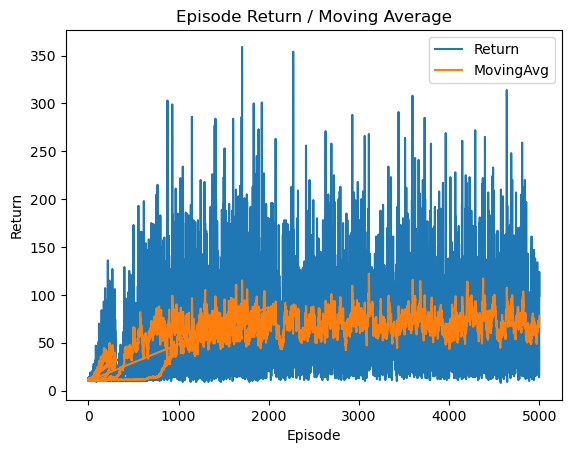

[SAVE] runs/qrl_cartpole_min\curve_returns.png


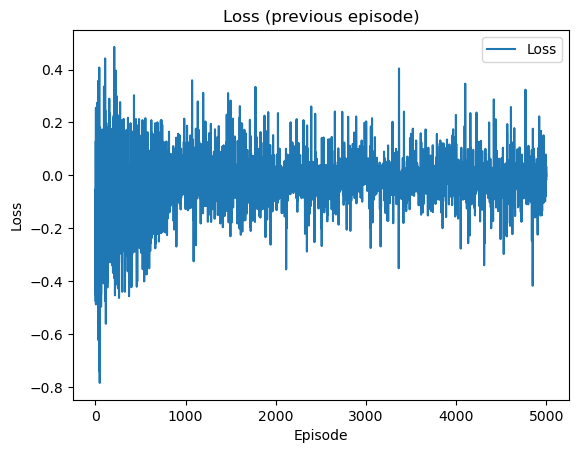

[SAVE] runs/qrl_cartpole_min\curve_loss.png


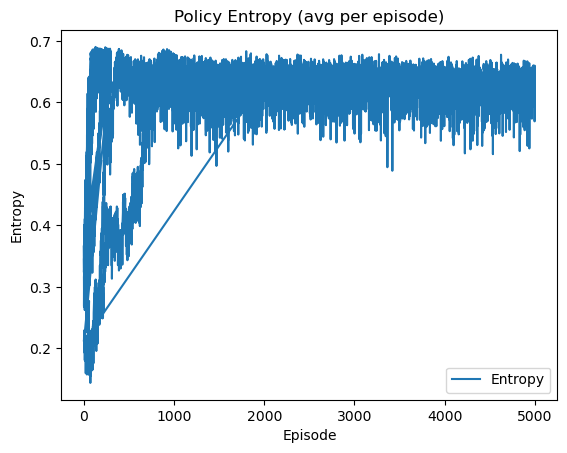

[SAVE] runs/qrl_cartpole_min\curve_entropy.png
[CKPT] 로드: runs/qrl_cartpole_min\weights_ep990.npy
[EVAL] deterministic avg return over 5 eps: 277.0 ± 0.0


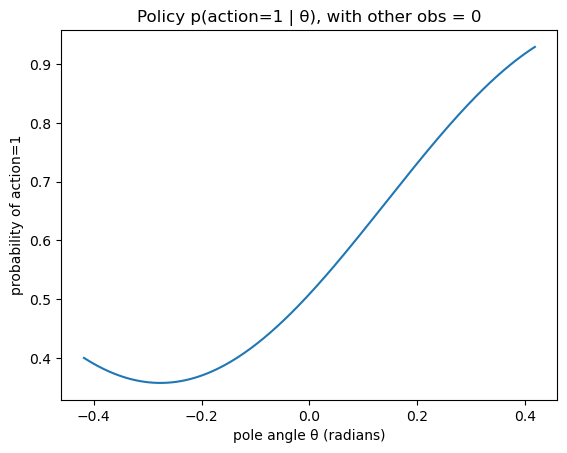

[SAVE] runs/qrl_cartpole_min\prob_vs_theta.png
[INFO] 분석/시각화 완료.


In [44]:
# 10) 학습 정보 정리
def load_training_log(csv_path: str) -> Optional[Dict[str, np.ndarray]]:
    if not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0:
        print(f"[WARN] 로그 파일이 없습니다: {csv_path}")
        return None
    cols = {
        "episode": [],
        "return": [],
        "moving_avg": [],
        "loss_prev": [],
        "avg_entropy": [],
        "steps": [],
        "eval_avg_return": [],
    }
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            cols["episode"].append(int(row["episode"]))
            cols["return"].append(float(row["return"]))
            cols["moving_avg"].append(float(row["moving_avg"]))
            cols["loss_prev"].append(float(row["loss_prev"]))
            cols["avg_entropy"].append(float(row["avg_entropy"]))
            cols["steps"].append(int(row["steps"]))
            # 빈 칸일 수 있음 → NaN으로 처리
            ev = row.get("eval_avg_return", "")
            cols["eval_avg_return"].append(float(ev) if ev not in (None, "",) else np.nan)
    for k in cols:
        cols[k] = np.asarray(cols[k])
    return cols

def plot_returns(log, save_dir: str):
    plt.figure()
    plt.title("Episode Return / Moving Average")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.plot(log["episode"], log["return"], label="Return")
    plt.plot(log["episode"], log["moving_avg"], label="MovingAvg")
    plt.legend()
    out = os.path.join(save_dir, "curve_returns.png")
    plt.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"[SAVE] {out}")

def plot_loss(log, save_dir: str):
    plt.figure()
    plt.title("Loss (previous episode)")
    plt.xlabel("Episode")
    plt.ylabel("Loss")
    plt.plot(log["episode"], log["loss_prev"], label="Loss")
    plt.legend()
    out = os.path.join(save_dir, "curve_loss.png")
    plt.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"[SAVE] {out}")

def plot_entropy(log, save_dir: str):
    plt.figure()
    plt.title("Policy Entropy (avg per episode)")
    plt.xlabel("Episode")
    plt.ylabel("Entropy")
    plt.plot(log["episode"], log["avg_entropy"], label="Entropy")
    plt.legend()
    out = os.path.join(save_dir, "curve_entropy.png")
    plt.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"[SAVE] {out}")
    

def find_latest_checkpoint(log_dir: str) -> Optional[str]:
    files = sorted(glob.glob(os.path.join(log_dir, "weights_ep*.npy")))
    return files[-1] if files else None

def load_weights_from_npy(path: str) -> pnp.ndarray:
    arr = np.load(path)
    # 평가만 할 것이므로 requires_grad는 False여도 무방
    return pnp.array(arr, requires_grad=False)

def get_eval_weights() -> pnp.ndarray:
    # 우선: 가장 최근 체크포인트 → 없으면 현재 세션의 weights → 없으면 새 초기화
    ckpt = find_latest_checkpoint(LOG_DIR)
    if ckpt:
        print(f"[CKPT] 로드: {ckpt}")
        return load_weights_from_npy(ckpt)
    print("[CKPT] 최근 체크포인트 없음. 현재 weights 변수 사용 시도.")
    if "weights" in globals():
        return weights
    print("[CKPT] 현재 weights도 없음. 임시 초기화 사용.")
    return init_weights(scale=0.01, seed=SEED + 777)

def run_eval(weights_eval, episodes: int = 5):
    try:
        avg, std = evaluate_policy(weights_eval, episodes=episodes)  # Cell 9 함수
        print(f"[EVAL] deterministic avg return over {episodes} eps: {avg:.1f} ± {std:.1f}")
        return avg, std
    except NameError:
        # 셀 9가 실행되지 않은 경우를 대비한 간이 평가
        env = EnvWrapper()
        rets = []
        for _ in range(episodes):
            batch, traj, stats = run_episode(env, weights_eval, deterministic=True)
            rets.append(stats["return"])
        env.close()
        avg, std = float(np.mean(rets)), float(np.std(rets)) if len(rets) > 1 else 0.0
        print(f"[EVAL*] avg return over {episodes} eps: {avg:.1f} ± {std:.1f}")
        return avg, std
    
def plot_prob_vs_theta(weights_eval, save_dir: str):
    # CartPole의 관측은 [x, x_dot, theta, theta_dot]
    # θ 범위: [-OBS_BOUNDS[2], OBS_BOUNDS[2]]
    thetas = np.linspace(-float(OBS_BOUNDS[2]), float(OBS_BOUNDS[2]), 201)
    probs = []
    for th in thetas:
        obs = np.array([0.0, 0.0, th, 0.0], dtype=np.float64)
        p = action_prob(weights_eval, obs)  # Cell 6
        probs.append(float(p))
    probs = np.asarray(probs)

    plt.figure()
    plt.title("Policy p(action=1 | θ), with other obs = 0")
    plt.xlabel("pole angle θ (radians)")
    plt.ylabel("probability of action=1")
    plt.plot(thetas, probs)
    out = os.path.join(save_dir, "prob_vs_theta.png")
    plt.savefig(out, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"[SAVE] {out}")

os.makedirs(LOG_DIR, exist_ok=True)

# (A) 로그 로드/플롯
log = load_training_log(CSV_PATH)
if log is not None:
    plot_returns(log, LOG_DIR)
    plot_loss(log, LOG_DIR)
    plot_entropy(log, LOG_DIR)

# (B) 정책 평가
w_eval = get_eval_weights()
_ = run_eval(w_eval, episodes=5)

# (C) θ-스윕 확률 곡선
plot_prob_vs_theta(w_eval, LOG_DIR)

print("[INFO] 분석/시각화 완료.")

In [45]:
# Gym/Gymnasium 반환 형식 호환 언팩
def _unpack_step(ret):
    if isinstance(ret, tuple) and len(ret) == 5:
        obs, reward, terminated, truncated, info = ret
        return obs, reward, bool(terminated or truncated), info
    elif isinstance(ret, tuple) and len(ret) == 4:
        obs, reward, done, info = ret
        return obs, reward, bool(done), info
    raise RuntimeError(f"알 수 없는 step 반환형: {type(ret)}, len={len(ret) if isinstance(ret, tuple) else 'n/a'}")

def find_latest_checkpoint(log_dir: str = LOG_DIR):
    files = sorted(glob.glob(os.path.join(log_dir, "weights_ep*.npy")))
    return files[-1] if files else None

def load_weights_from_npy(path: str):
    arr = np.load(path)  # (N_LAYERS, N_QUBITS, 2)
    # 평가만 할거라 requires_grad는 필요 없음
    from pennylane import numpy as pnp
    return pnp.array(arr, requires_grad=False)

def play_trained(
    weights_eval=None,
    episodes: int = 3,
    fps: int = 60,
    hold_after_done: bool = True,
):
    """
    학습 완료 정책으로 pygame 창에서 재생.
    - weights_eval: None이면 최신 체크포인트 → 없으면 현재 전역 weights
    - episodes: 연속 재생할 에피소드 수
    - fps: 재생 속도(너무 높으면 빠르게 지나가 보일 수 있음)
    - hold_after_done: 마지막 에피소드 종료 후, 사람이 창을 닫을 때까지 유지
    """
    # 0) 가중치 결정
    if weights_eval is None:
        ckpt = find_latest_checkpoint(LOG_DIR)
        if ckpt:
            print(f"[PLAY] 체크포인트 로드: {ckpt}")
            weights_eval = load_weights_from_npy(ckpt)
        elif "weights" in globals():
            print("[PLAY] 현재 세션의 weights 사용")
            weights_eval = weights
        else:
            raise RuntimeError("weights가 없습니다. 학습을 먼저 실행하거나 체크포인트(.npy)를 준비하세요.")

    # 1) pygame 창으로 human 렌더
    env = gym.make(ENV_ID, render_mode="human")
    target_dt = 1.0 / max(1, int(fps))

    total_returns = []
    for ep in range(episodes):
        obs, _ = env.reset()
        ep_return = 0.0
        steps = 0

        while True:
            t0 = time.time()
            # 결정적 정책: p>=0.5 → 1
            act, p = sample_action(weights_eval, obs, deterministic=True)  # (Cell 6)
            obs, reward, done, info = _unpack_step(env.step(int(act)))
            ep_return += float(reward)
            steps += 1

            # 일부 환경/버전에선 render() 호출이 필요할 수 있음(무해)
            try:
                env.render()
            except Exception:
                pass

            # FPS 유지
            dt = time.time() - t0
            if dt < target_dt:
                time.sleep(target_dt - dt)
            if done:
                break

        print(f"[PLAY] episode {ep+1}/{episodes} — return={ep_return:.1f}, steps={steps}")
        total_returns.append(ep_return)

    # 2) 마지막 프레임 유지(사람이 창을 닫을 때까지)
    if hold_after_done:
        try:
            import pygame
            clock = pygame.time.Clock()
            running = True
            print("[PLAY] 창을 닫으려면 ESC 또는 창 닫기(×)를 누르세요.")
            while running:
                try:
                    env.render()
                except Exception:
                    break
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                    if event.type == pygame.KEYDOWN and event.key in (pygame.K_ESCAPE, pygame.K_q):
                        running = False
                clock.tick(30)
        except Exception as e:
            print(f"[PLAY] hold 모드 중 경고: {e}")

    env.close()
    return float(np.mean(total_returns)), float(np.std(total_returns)) if len(total_returns) > 1 else 0.0

# === 사용 예시 ===
# 1) 최신 체크포인트로 3판 연속 재생 후, 창 유지
avg, std = play_trained(weights_eval=None, episodes=3, fps=60, hold_after_done=True)
print(f"[PLAY] 평균 리턴 = {avg:.1f} ± {std:.1f}")

# 2) 현재 세션의 weights로 1판만 빠르게 재생(끝나면 바로 닫기)
# avg, std = play_trained(weights_eval=weights, episodes=1, fps=60, hold_after_done=False)

[PLAY] 체크포인트 로드: runs/qrl_cartpole_min\weights_ep990.npy
[PLAY] episode 1/3 — return=143.0, steps=143
[PLAY] episode 2/3 — return=110.0, steps=110
[PLAY] episode 3/3 — return=139.0, steps=139
[PLAY] 창을 닫으려면 ESC 또는 창 닫기(×)를 누르세요.
[PLAY] 평균 리턴 = 130.7 ± 14.7
